# Home Credit Default Risk

Ноутбук с базовой загрузкой данных, feature engineering и сравнением baseline-моделей.


In [41]:
import lightgbm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from src.data_loader import load_core_tables
from src.features import merge_bureau_features, merge_bureau_balance_features, merge_credit_credit_features, \
    merge_installments_payments_features


In [2]:
tables = load_core_tables('.')
train = merge_bureau_features(tables['application_train'], tables['bureau'])
train = merge_bureau_balance_features(train, tables['bureau'], tables['bureau_balance'])
train = merge_credit_credit_features(train, tables['credit_card_balance'])
train = merge_installments_payments_features(train, tables['installments_payments'])

In [5]:
train.shape

(307511, 193)

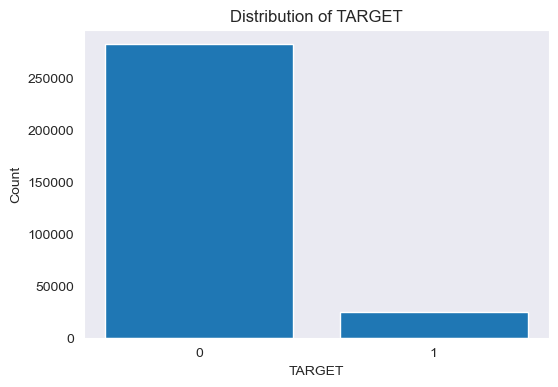

<Figure size 600x400 with 0 Axes>

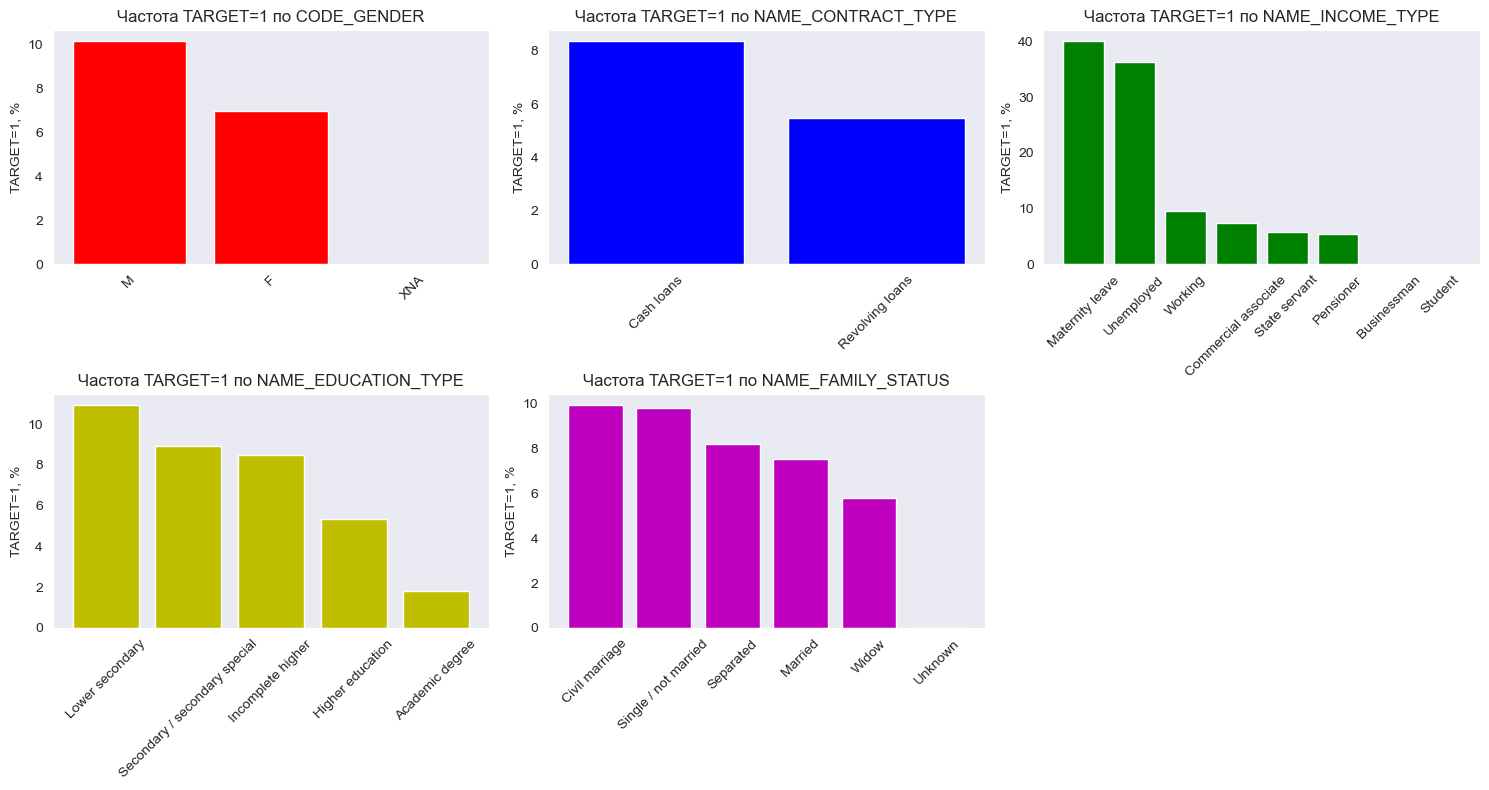

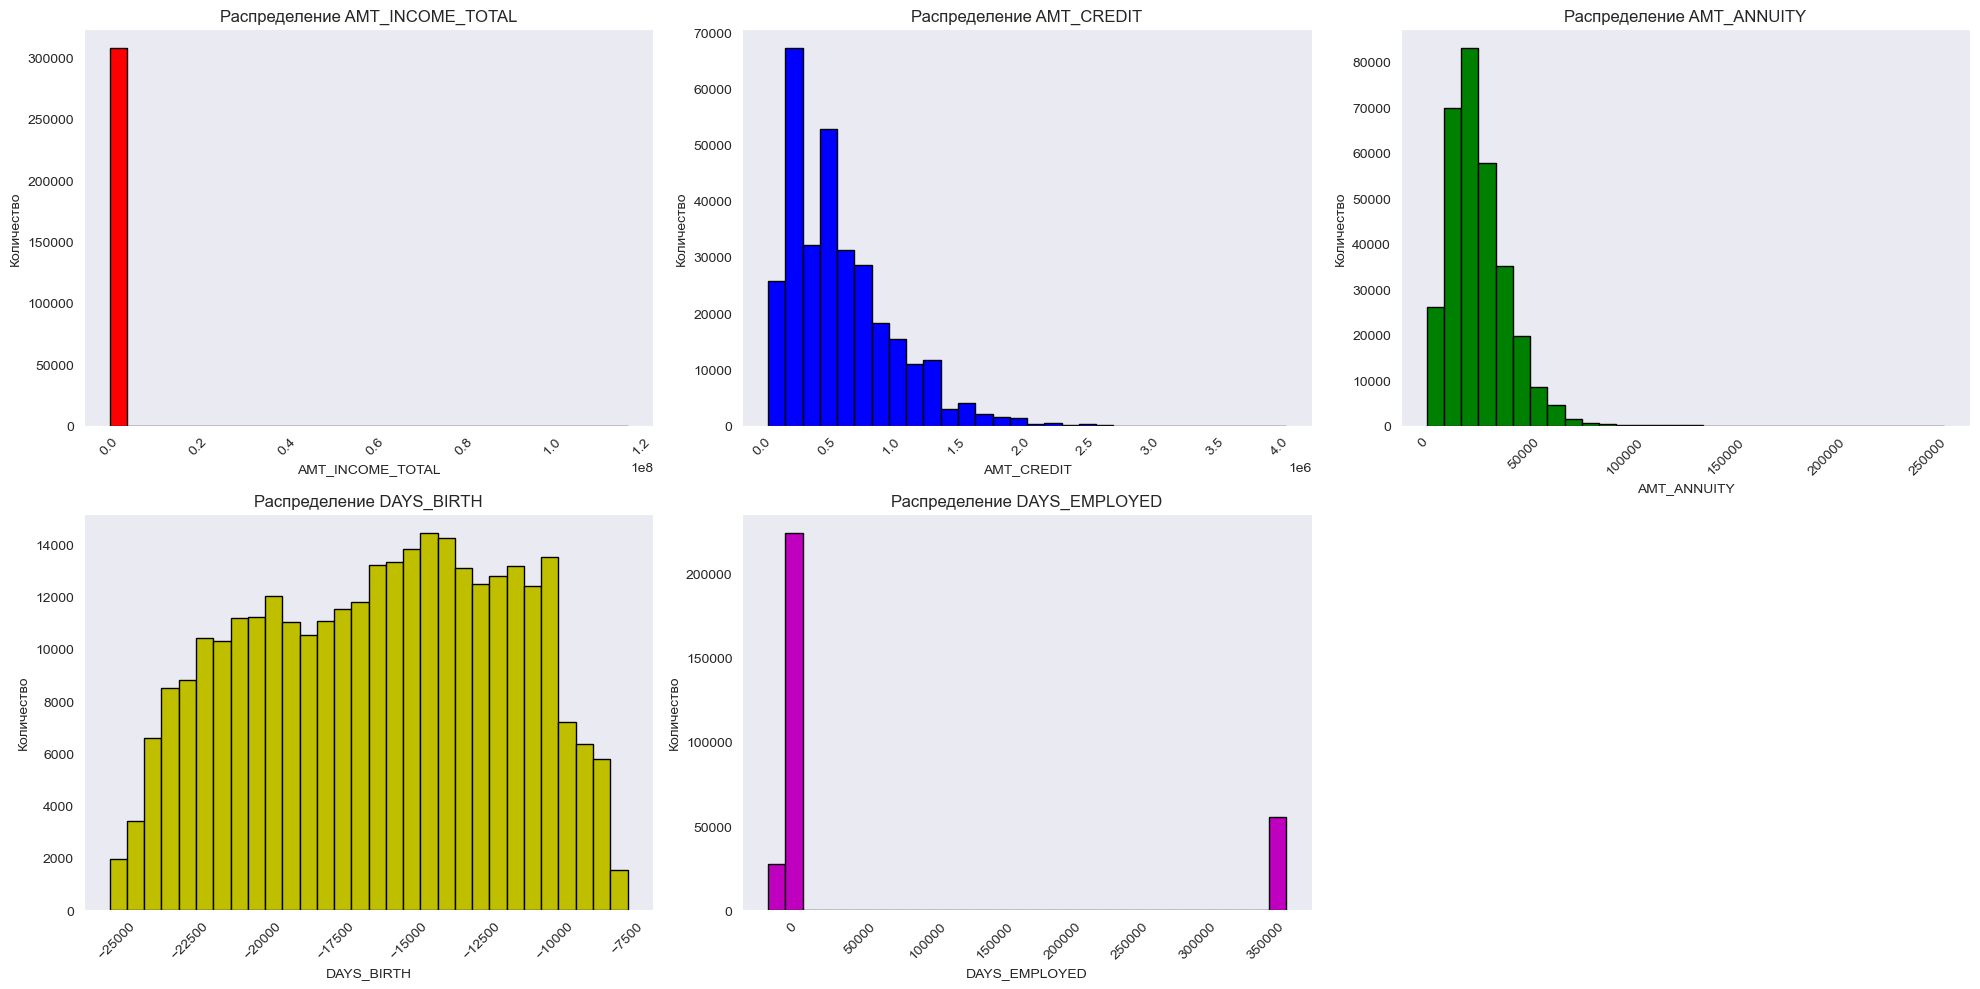

In [6]:
target_counts = train['TARGET'].value_counts()
import seaborn as sns

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title('Distribution of TARGET')
plt.xlabel('TARGET')
plt.ylabel('Count')
plt.grid()
plt.show()

plt.figure(figsize=(6, 4))
cols = [
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS"
]
color = ['r', 'b', 'g', 'y', 'm', 'w']
i = 0
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()
for j, col in enumerate(cols):
    rate = (train.groupby(col)["TARGET"].mean() * 100).sort_values(ascending=False)
    color_current = color[i]
    axes[j].bar(rate.index, rate.values, color=color_current)
    axes[j].set_title(f"Частота TARGET=1 по {col}")
    axes[j].set_ylabel("TARGET=1, %")
    axes[j].set_xlabel("")
    axes[j].tick_params(axis="x", rotation=45)
    axes[j].grid()
    i += 1
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
col_money = ['AMT_INCOME_TOTAL',
             'AMT_CREDIT',
             'AMT_ANNUITY',
             'DAYS_BIRTH',
             'DAYS_EMPLOYED']
axes = axes.flatten()
for j, col in enumerate(col_money):
    values = train[col]
    color_current = color[j]
    axes[j].hist(values, bins=30, color=color_current, edgecolor="black")
    axes[j].set_title(f"Распределение {col}")
    axes[j].set_ylabel("Количество")
    axes[j].set_xlabel(col)
    axes[j].tick_params(axis="x", rotation=45)
    axes[j].grid()
plt.tight_layout()
fig.delaxes(axes[5])
plt.show()

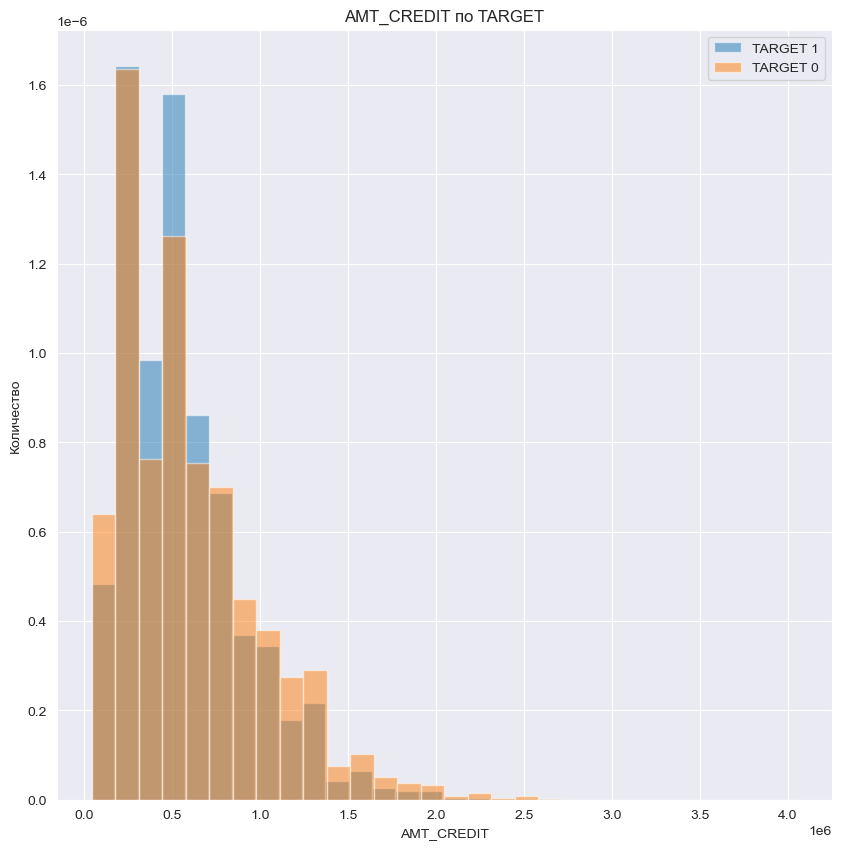

In [7]:
plt.figure(figsize=(10, 10))
plt.hist(train[train['TARGET'] == 1]['AMT_CREDIT'], bins=30, alpha=0.5, label='TARGET 1', density=True)
plt.hist(train[train['TARGET'] == 0]['AMT_CREDIT'], bins=30, alpha=0.5, label='TARGET 0', density=True)
plt.title("AMT_CREDIT по TARGET")
plt.xlabel("AMT_CREDIT")
plt.ylabel("Количество")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\myska\AppData\Local\Temp\ipykernel_5372\390797134.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = train.groupby(credit_bins)["TARGET"].mean() * 100


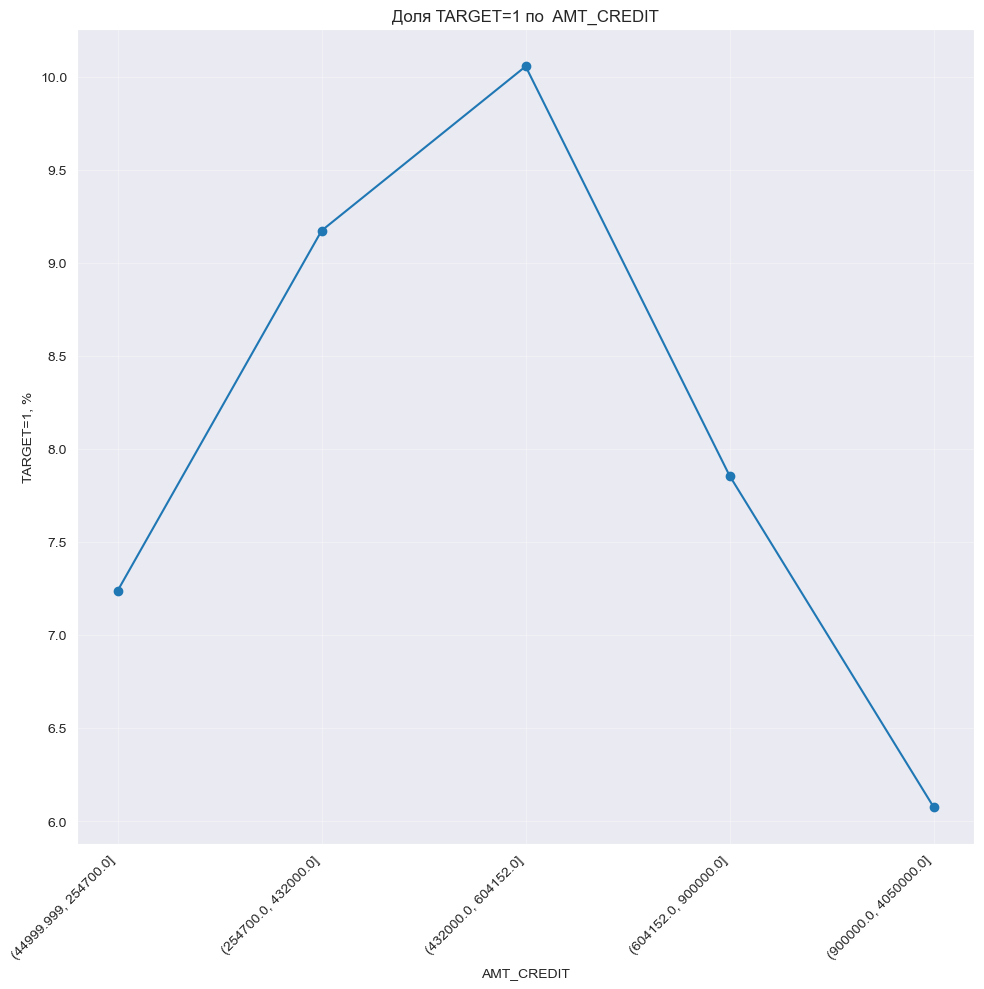

In [8]:
credit_bins = pd.qcut(train["AMT_CREDIT"], q=5)
rate = train.groupby(credit_bins)["TARGET"].mean() * 100
plt.figure(figsize=(10, 10))
plt.plot(rate.index.astype(str), rate.values, marker="o")
plt.title("Доля TARGET=1 по  AMT_CREDIT")
plt.xlabel("AMT_CREDIT")
plt.ylabel("TARGET=1, %")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

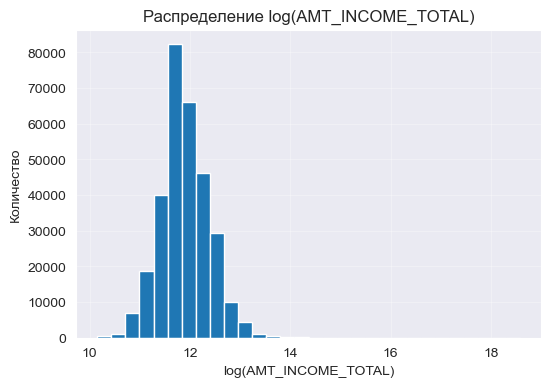

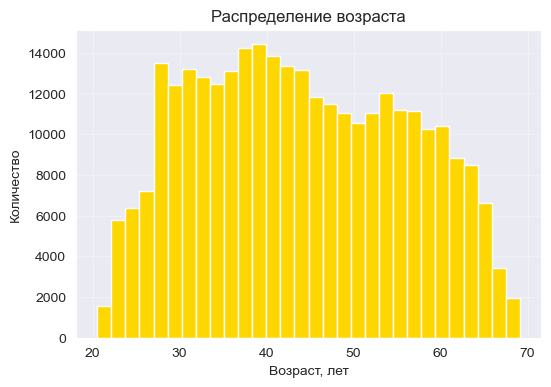

In [9]:
train["DAYS_EMPLOYED"] = train["DAYS_EMPLOYED"].replace(365243, np.nan)
plt.figure(figsize=(6, 4))
plt.hist(np.log1p(train["AMT_INCOME_TOTAL"].dropna()), bins=30)
plt.title("Распределение log(AMT_INCOME_TOTAL)")
plt.xlabel("log(AMT_INCOME_TOTAL)")
plt.ylabel("Количество")
plt.grid(alpha=0.3)
plt.show()
train['age_years'] = -train["DAYS_BIRTH"] / 365

plt.figure(figsize=(6, 4))
plt.hist(train['age_years'].dropna(), bins=30, color="gold")
plt.title("Распределение возраста")
plt.xlabel("Возраст, лет")
plt.ylabel("Количество")
plt.grid(alpha=0.3)
plt.show()

## Обработка пропусков и подготовка признаков

Заполнение пропусков и финализация набора признаков перед моделированием.


In [10]:
few_passes = ['DAYS_LAST_PHONE_CHANGE',
              'CNT_FAM_MEMBERS',
              'AMT_ANNUITY',
              'AMT_GOODS_PRICE']
train[few_passes] = train[few_passes].fillna(train[few_passes].mean())
social_columns = ['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
                  'DEF_60_CNT_SOCIAL_CIRCLE']
train[social_columns] = train[social_columns].fillna(0)
amt_req = [col for col in train.columns if col.startswith('AMT_REQ_CREDIT_BUREAU')]
for i in range(len(amt_req)):
    train[f'have_checked_req_credit_{i}'] = (train[amt_req[i]] > 0).astype(int)
train[amt_req] = train[amt_req].fillna(0)

In [14]:
ext_sour = [col for col in train.columns if col.startswith('EXT_SOURCE_')]
for ext in ext_sour:
    train[ext] = train[ext].fillna(train[ext].mean())
past_end = [col for col in train.columns if col.startswith('PAST_END')]
early_close = [col for col in train.columns if col.startswith('EARLY_CLOSE')]
ins_col = [col for col in train.columns if col.startswith('INS')]
train[ins_col] = train[ins_col].fillna(0)
credit_cols = [
    'CREDIT_COUNT', 'CREDIT_MEAN', 'CREDIT_MAX',
    'ACTIVE_CREDIT_SUM', 'ACTIVE_CREDIT_MEAN',
    'CREDIT_DAY_OVERDUE_SUM', 'CREDIT_DAY_OVERDUE_MAX',
    'CREDIT_DAY_OVERDUE_MIN', 'CREDIT_DAY_OVERDUE_MEAN',
    'DAYS_CREDIT_ENDDATE_MIN', 'DAYS_CREDIT_ENDDATE_MAX',
    'DAYS_CREDIT_ENDDATE_MEAN', 'DAYS_ENDDATE_FACT_MEAN'
]
bureau_features = [
    'CREDIT_SUM',
    'DAYS_CREDIT_MOST_RECENT',
    'DAYS_CREDIT_MEAN',
    'DAYS_CREDIT_OLDEST',
    'DAYS_CREDIT_ENDDATE_SUM'
]
train['OWN_CAR_AGE'] = train['OWN_CAR_AGE'].fillna(0)
train[credit_cols] = train[credit_cols].fillna(0)
train[bureau_features] = train[bureau_features].fillna(0)
for past in past_end:
    train[past] = train[past].fillna(0)
for early in early_close:
    train[early] = train[early].fillna(0)

In [15]:
categorical = [
    'NAME_TYPE_SUITE',
    'OCCUPATION_TYPE',
    'EMERGENCYSTATE_MODE',
    'HOUSETYPE_MODE',
    'WALLSMATERIAL_MODE',
    'FONDKAPREMONT_MODE'
]
loan_types = [
    'Another type of loan',
    'Car loan',
    'Loan for business development',
    'Consumer credit',
    'Credit card',
    'Interbank credit',
    'Loan for the purchase of equipment',
    'Loan for purchase of shares (margin lending)',
    'Loan for working capital replenishment',
    'Cash loan (non-earmarked)',
    'Real estate loan',
    'Mortgage',
    'Mobile operator loan',
    'Unknown type of loan',
    'Microloan'
]
housing = [
    'TOTALAREA_MODE',

    'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BUILD_AVG', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE',

    'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE',
    'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE',

    'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE',
    'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE',

    'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE',
    'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE',

    'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE',
    'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE',
    'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE',

    'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE',
    'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE'
]
train[categorical] = train[categorical].fillna('Unknown')
train[loan_types] = train[loan_types].fillna(0)
train[housing] = train[housing].fillna(-1)
bb_cols = [col for col in train.columns if col.startswith("BB_")]
train[bb_cols] = train[bb_cols].fillna(0)
train[bb_cols] = train[bb_cols].fillna(0)
credit_card_cols = [
    "balance_to_limit_mean",
    "balance_to_limit_max",
    "dpd_mean",
    "dpd_max",
    "payment_to_min_mean",
    "payment_to_min_max",
    "payment_to_balance_mean",
    "payment_to_balance_max",
    "drawings_to_limit_mean",
    "drawings_to_limit_max",
]

train[credit_card_cols] = train[credit_card_cols].fillna(0)
train["DAYS_EMPLOYED"] = train["DAYS_EMPLOYED"].fillna(train["DAYS_EMPLOYED"].median())
train = train.copy()
train['credit_income_credit'] = train['AMT_CREDIT'] / train[
    'AMT_INCOME_TOTAL']
train['annuity_to_income'] = train['AMT_ANNUITY'] / train[
    'AMT_INCOME_TOTAL']
train['income_for_person'] = train['AMT_INCOME_TOTAL'] / train[
    'CNT_FAM_MEMBERS']
train['EXT_SOURCE_MEAN'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
train['EXT_SOURCE_MAX'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)
train['EXT_SOURCE_MIN'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
train['EXT_SOURCE_STD'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

In [16]:
train.isnull().sum().sort_values(ascending=False).head(30)



SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
FLAG_OWN_REALTY               0
CNT_CHILDREN                  0
AMT_INCOME_TOTAL              0
AMT_CREDIT                    0
AMT_ANNUITY                   0
AMT_GOODS_PRICE               0
NAME_TYPE_SUITE               0
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
NAME_FAMILY_STATUS            0
NAME_HOUSING_TYPE             0
REGION_POPULATION_RELATIVE    0
DAYS_BIRTH                    0
DAYS_EMPLOYED                 0
DAYS_REGISTRATION             0
DAYS_ID_PUBLISH               0
OWN_CAR_AGE                   0
FLAG_MOBIL                    0
FLAG_EMP_PHONE                0
FLAG_WORK_PHONE               0
FLAG_CONT_MOBILE              0
FLAG_PHONE                    0
FLAG_EMAIL                    0
OCCUPATION_TYPE               0
CNT_FAM_MEMBERS               0
dtype: int64

## Подготовка выборок

Разделение данных и one-hot encoding категориальных признаков.


In [23]:
def get_train_test_data(train: pd.DataFrame):
    Y = train['TARGET']
    X = train.drop('TARGET', axis=1)
    cat_cols = X.select_dtypes(include=['object']).columns

    x_train, x_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42, stratify=Y
    )
    x_train_for_catboost = x_train
    x_test_for_catboost = x_test
    y_train_for_catboost = y_train
    y_test_for_catboost = y_test
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    x_train_ohe = ohe.fit_transform(x_train[cat_cols])
    x_train_ohe_df = pd.DataFrame(x_train_ohe, columns=ohe.get_feature_names_out(cat_cols), index=x_train.index)
    x_test_ohe = ohe.transform(x_test[cat_cols])
    x_test_ohe_df = pd.DataFrame(
        x_test_ohe,
        columns=ohe.get_feature_names_out(cat_cols),
        index=x_test.index
    )

    x_train = x_train.drop(columns=cat_cols)
    x_test = x_test.drop(columns=cat_cols)

    x_train = pd.concat([x_train, x_train_ohe_df], axis=1)
    x_test = pd.concat([x_test, x_test_ohe_df], axis=1)
    print(x_train.shape, x_test.shape)
    return x_train, x_test, y_train, y_test, x_train_for_catboost, x_test_for_catboost, y_train_for_catboost, y_test_for_catboost


In [45]:
models = {
    "LogisticRegression": {
        "model": LogisticRegression(
            random_state=42,
            max_iter=1000
        ),
        "scaled": True,
    },

    "RandomForest": {
        "model": RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
            verbose=True
        ),
        "scaled": False,
    },

    "LightGBM": {
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=100
        ),
        "scaled": False,
    },

    "CatBoost": {
        "model": CatBoostClassifier(
            iterations=500,
            learning_rate=0.03,
            depth=6,
            eval_metric="PRAUC",
            random_seed=42,
            verbose=100
        ),
        "scaled": False,
    },
}
x_train, x_test, y_train, y_test, x_train_for_catboost, x_test_for_catboost, y_train_for_catboost, y_test_for_catboost = get_train_test_data(
    train)

(246008, 336) (61503, 336)


Сейчас обучаем LogisticRegression


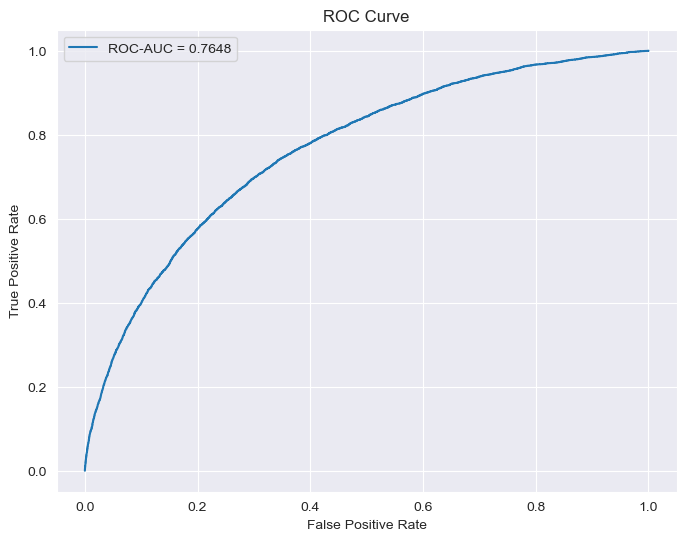

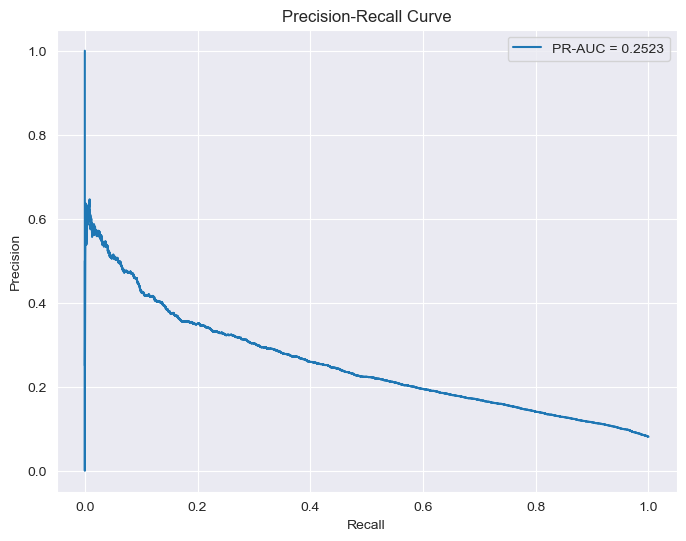

Сейчас обучаем RandomForest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   28.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished


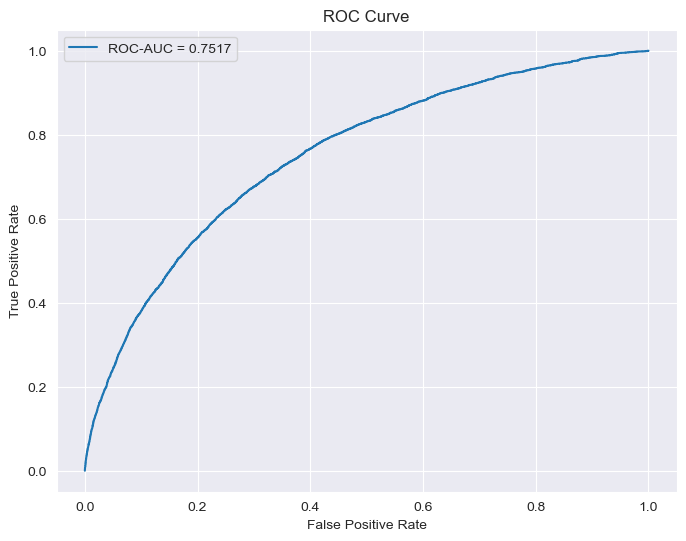

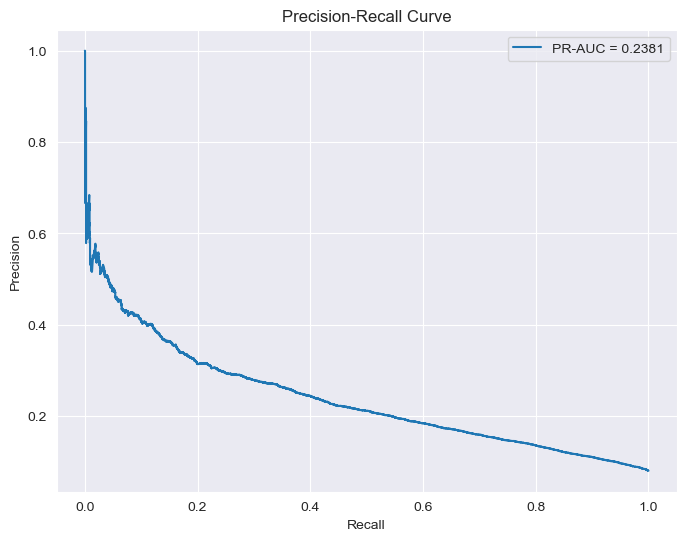

Сейчас обучаем LightGBM
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.938696
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.581326
[LightGBM] [Debug] init for col-wise cost 0.059623 seconds, init for row-wise cost 0.159065 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.177456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25882
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 320
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained

C:\Users\myska\anaconda3\envs\PythonProject1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\myska\anaconda3\envs\PythonProject1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


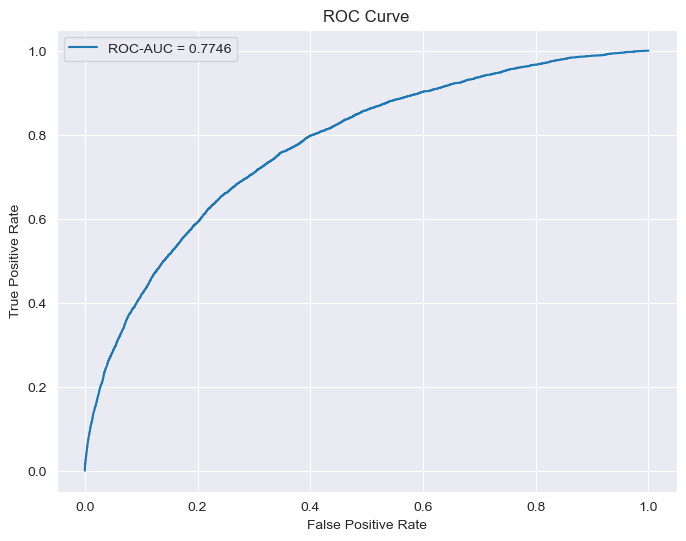

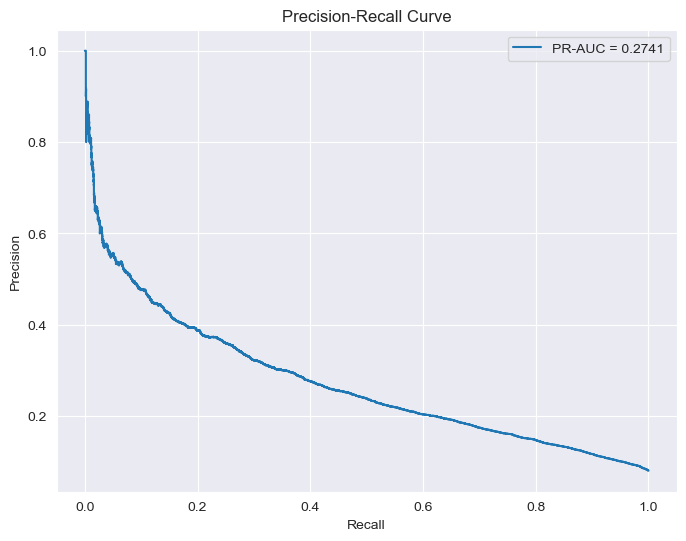

Сейчас обучаем CatBoost
0:	learn: 0.1505588	total: 461ms	remaining: 3m 50s
100:	learn: 0.2408687	total: 26.2s	remaining: 1m 43s
200:	learn: 0.2611877	total: 50.9s	remaining: 1m 15s
300:	learn: 0.2737454	total: 1m 17s	remaining: 50.9s
400:	learn: 0.2842583	total: 1m 42s	remaining: 25.3s
499:	learn: 0.2961105	total: 2m 6s	remaining: 0us


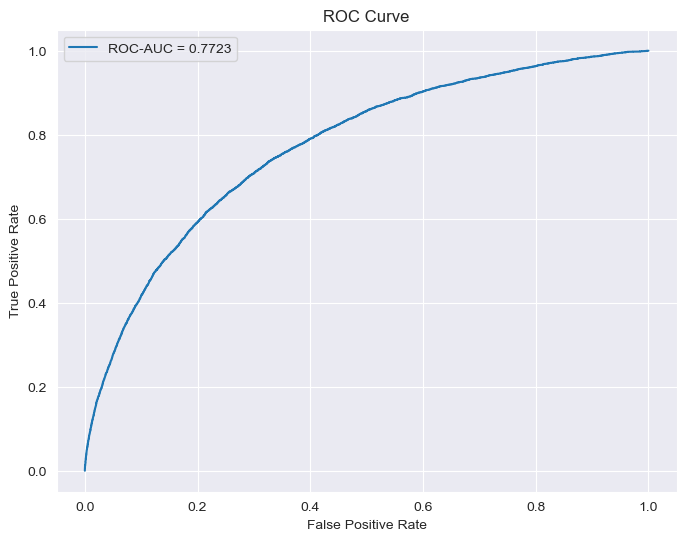

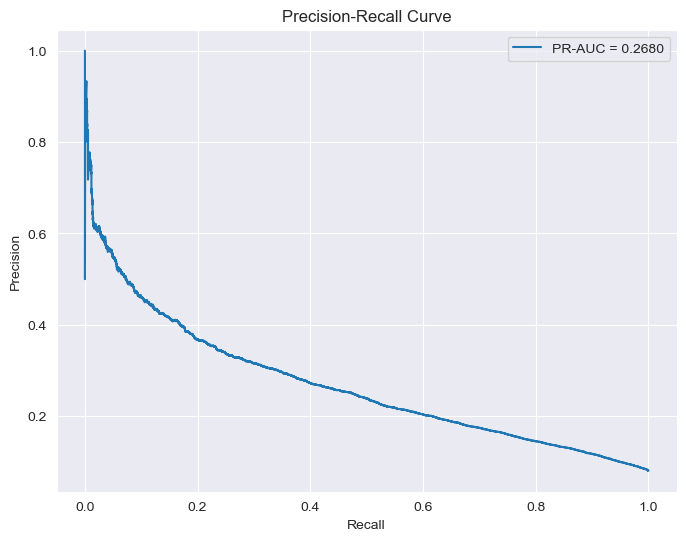

In [51]:
results_baseline = {}

for name, info in models.items():
    print(f'Сейчас обучаем {name}')
    model = info['model']
    if name == "CatBoost":
        model.fit(x_train_for_catboost, y_train,cat_features=cat_cols.to_list())
        y_proba = model.predict_proba(x_test_for_catboost)[:, 1]
        y_pred = model.predict(x_test_for_catboost)
    else:
        if info['scaled']:
            scaler = StandardScaler()
            x_train = scaler.fit_transform(x_train)
            x_test = scaler.transform(x_test)
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        y_proba = model.predict_proba(x_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_proba)
    fpr, tpr, threshold_roc = roc_curve(y_test, y_proba)
    accuracy = accuracy_score(y_test, y_pred)
    results_baseline[name] = {
        "model": model,
        "accuracy": accuracy,
        "precisions": precisions,
        "recalls": recalls,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "fpr": fpr,
        "tpr": tpr,
        "threshold_roc": threshold_roc,
        "thresholds_pr": thresholds_pr
    }


    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


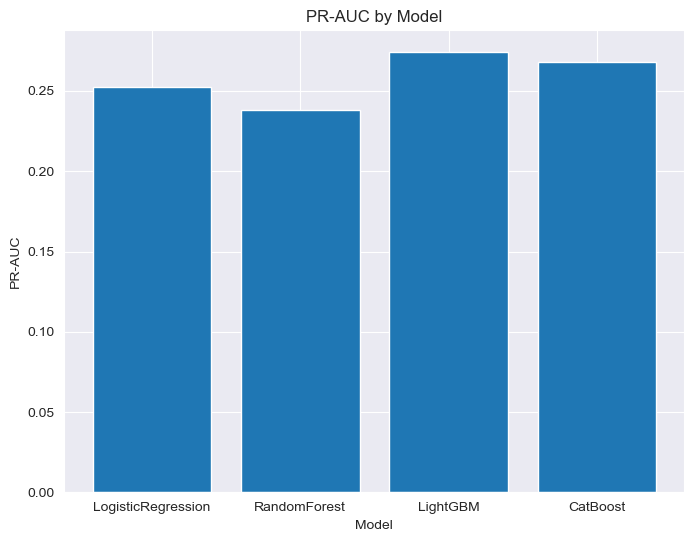

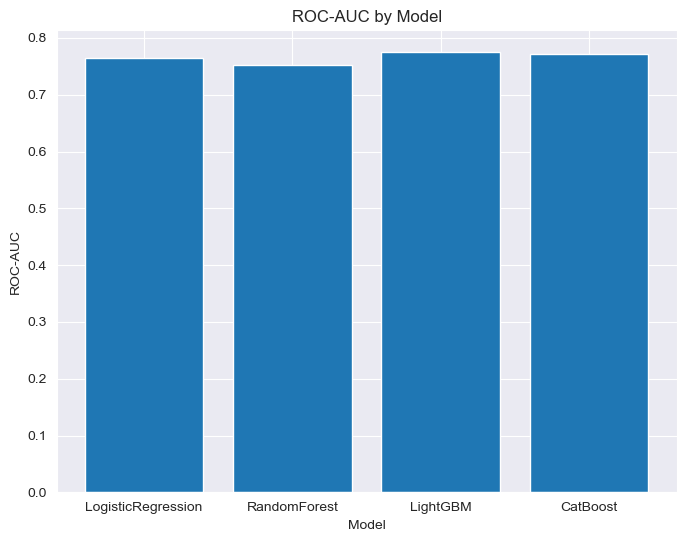

In [52]:
model_names = list(results_baseline.keys())
pr_aucs = [results_baseline[name]["pr_auc"] for name in model_names]
roc_aucs = [results_baseline[name]["roc_auc"] for name in model_names]

plt.figure(figsize=(8, 6))
plt.bar(model_names, pr_aucs)
plt.title("PR-AUC by Model")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(model_names, roc_aucs)
plt.title("ROC-AUC by Model")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.grid(True)
plt.show()

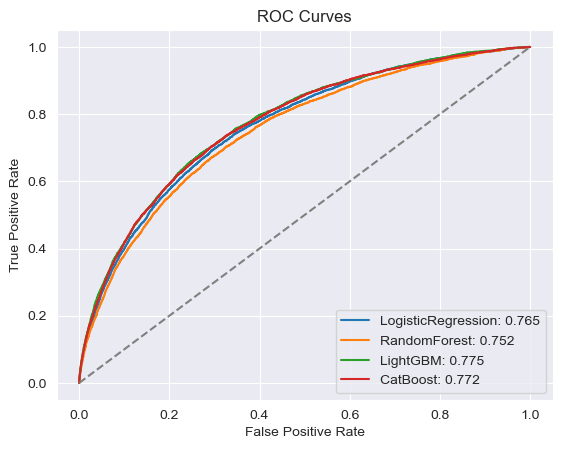

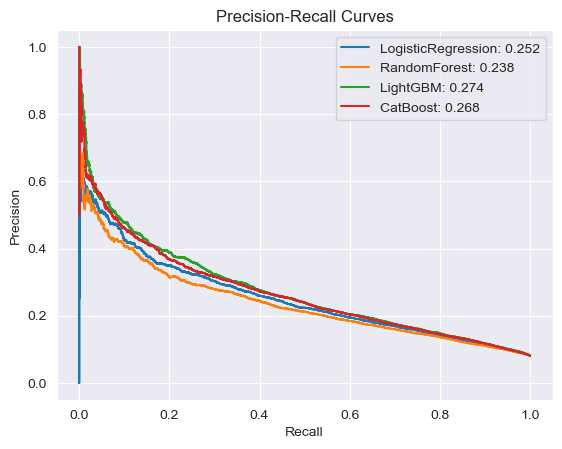

In [62]:
for name, metrics in results_baseline.items():
    plt.plot(metrics["fpr"], metrics["tpr"], label=f"{name}: {metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()
for name,metrics in results_baseline.items():
    plt.plot(metrics["recalls"],metrics['precisions'],label =f"{name}: {metrics['pr_auc']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

### _Берем, как основные модели LightGBM,CatBoost,LogisticRegression и будем их оптимизировать + добавим еще признаки с файла pos_cash_balance,previous_application_